### Trading effet de mode Crypto

## Mon hypothese est la suivante : 

Lorsque le Bitcoin performe, les altcoins qui lui sont fortement corrélés ont tendance à surperformer également, avec une volatilité plus élevée. 
Je cherche ici à exploiter un effet de mode passager sur une cryptomonnaie « tendance » afin de capter cette volatilité.

Dans l’hypothèse où le Bitcoin enregistre, sur une semaine, une performance nettement supérieure à son comportement habituel, concrètement, lorsque sa performance cumulée sur 5 jours dépasse d'au moins un écart-type sa médiane historique sur 5 jours, et qu’il évolue au‑dessus de sa moyenne mobile de moyen terme, on peut alors considérer que le contexte du marché crypto est haussier.

Dans cette configuration, mon intuition serait de s’exposer à la cryptomonnaie la plus performante parmi le top 15 des capitalisations au cours des 5 derniers jours (celle dont le rendement cumulé sur 5 jours est le plus élevé), afin de capter un effet de momentum et d’effet de mode sur cette cryptomonnaie, amplifié par la tendance dominante du Bitcoin.



In [3]:
# %% [markdown]
# === 1) Téléchargement 1x en mémoire (pas de CSV/Parquet), réutilisable dans tout le notebook ===

import time
import requests
import numpy as np
import pandas as pd
import os
import math
import time
import json
import requests
from datetime import datetime, timedelta, timezone
import numpy as np
import pandas as pd
import vectorbt as vbt
import plotly.express as px

# --- Paramètres ---
TOP_SYMBOLS = [
    "BTCUSDT", "ETHUSDT", "BNBUSDT", "SOLUSDT", "XRPUSDT",
    "ADAUSDT", "DOGEUSDT", "AVAXUSDT", "LINKUSDT", "TAOUSDT", "FETUSDT", "SUIUSDT", "AAVEUSDT"
]
API_BASE = "https://api.binance.com"
INTERVAL = "1d"
START_DATE = "2020-01-01"
MAX_SYMBOLS_PER_REQUEST = 1000 
ROLL_LOOKBACK = 600     # fenêtre en jours pour médiane/écart-type des perfs 5D
SLIPPAGE_BPS = 0        # glissement (0 = simplifié)
FEES_BPS = 6            # 0.06% par trade par ex. (ajuste si besoin)
TZ = "UTC"    # limite klines par appel

# Cache RAM pour cette session (évite tout re-download si tu ré-exécutes une cellule)
_RAM_KLINES: dict[str, pd.DataFrame] = {}

# Session HTTP réutilisée (plus efficace)
_SESSION = requests.Session()

def binance_klines(symbol: str, interval: str, start_dt: str) -> pd.DataFrame:
    """Télécharge toutes les bougies 1D pour `symbol` depuis `start_dt` via pagination.
       Retourne DataFrame indexé par date (UTC) avec colonnes: open, high, low, close, volume.
       (Téléchargé 1x puis stocké en RAM)
    """
    # Si déjà en RAM → renvoie direct
    key = f"{symbol}|{interval}|{start_dt}"
    if key in _RAM_KLINES:
        return _RAM_KLINES[key]

    url = f"{API_BASE}/api/v3/klines"
    start_ms = int(pd.Timestamp(start_dt, tz="UTC").timestamp() * 1000)
    all_rows = []
    backoff = 0.2

    while True:
        params = {
            "symbol": symbol,
            "interval": interval,
            "startTime": start_ms,
            "limit": MAX_SYMBOLS_PER_REQUEST
        }
        r = _SESSION.get(url, params=params, timeout=30)
        # gestion douce des limites API
        if r.status_code == 429:
            time.sleep(backoff)
            backoff = min(backoff * 2, 5)  # backoff max 5s
            continue
        r.raise_for_status()

        rows = r.json()
        if not rows:
            break

        all_rows.extend(rows)

        last_close_ms = rows[-1][6]
        next_start_ms = last_close_ms + 1
        if next_start_ms == start_ms:
            break
        start_ms = next_start_ms

        # petit sleep pour ne pas spam l'API
        time.sleep(0.08)

    if not all_rows:
        df = pd.DataFrame(columns=["open","high","low","close","volume"])
        _RAM_KLINES[key] = df
        return df

    cols = [
        "open_time","open","high","low","close","volume",
        "close_time","quote_asset_volume","number_of_trades",
        "taker_buy_base_vol","taker_buy_quote_vol","ignore"
    ]
    df = pd.DataFrame(all_rows, columns=cols)
    df["open_time"]  = pd.to_datetime(df["open_time"],  unit="ms", utc=True)
    df["close_time"] = pd.to_datetime(df["close_time"], unit="ms", utc=True)

    for c in ["open","high","low","close","volume"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    # index = close_time (daily UTC)
    df = df.set_index("close_time").sort_index()
    df = df[["open","high","low","close","volume"]]

    _RAM_KLINES[key] = df  # **cache RAM**
    return df

# --- Téléchargement 1x de tout l'univers en RAM ---
data_map = {}
for sym in TOP_SYMBOLS:
    print("Fetching:", sym)
    data_map[sym] = binance_klines(sym, INTERVAL, START_DATE)

# Harmoniser l'univers (intersection des dates disponibles) en mémoire
all_closes = pd.concat(
    {sym: data_map[sym]["close"] for sym in TOP_SYMBOLS if not data_map[sym].empty},
    axis=1
).dropna(how="any")

all_opens = pd.concat(
    {sym: data_map[sym]["open"] for sym in TOP_SYMBOLS if not data_map[sym].empty},
    axis=1
).reindex(all_closes.index).dropna(how="any")



Fetching: BTCUSDT
Fetching: ETHUSDT
Fetching: BNBUSDT
Fetching: SOLUSDT
Fetching: XRPUSDT
Fetching: ADAUSDT
Fetching: DOGEUSDT
Fetching: AVAXUSDT
Fetching: LINKUSDT
Fetching: TAOUSDT
Fetching: FETUSDT
Fetching: SUIUSDT
Fetching: AAVEUSDT
OK: data en RAM → all_closes.shape: (580, 13)


C:\Users\leoja\AppData\Local\Temp\ipykernel_16820\2954644623.py:29: FutureWarning:

The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError



Start                         2024-04-11 23:59:59.999000+00:00
End                           2025-11-11 23:59:59.999000+00:00
Period                                       580 days 00:00:00
Start Value                                            10000.0
End Value                                              10000.0
Total Return [%]                                           0.0
Benchmark Return [%]                                 21.903793
Max Gross Exposure [%]                                     0.0
Total Fees Paid                                            0.0
Max Drawdown [%]                                           NaN
Max Drawdown Duration                                      NaT
Total Trades                                                 0
Total Closed Trades                                          0
Total Open Trades                                            0
Open Trade PnL                                             0.0
Win Rate [%]                                           

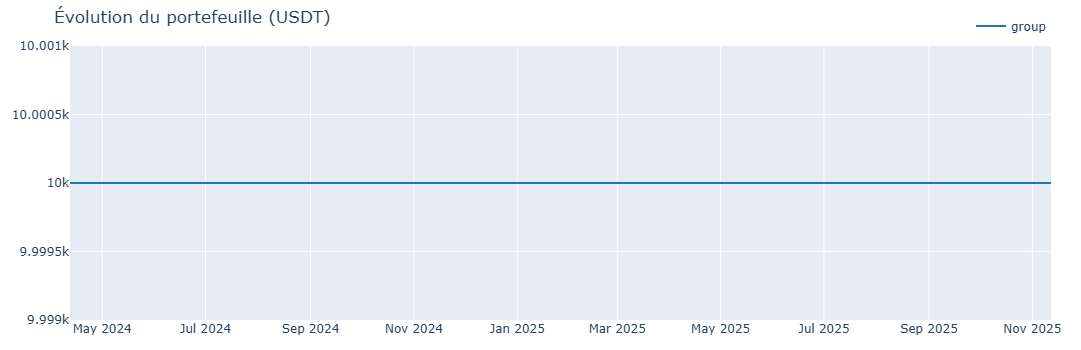

,Exit Trade Id,Column,Size,Entry Timestamp,Avg Entry Price,Entry Fees,Exit Timestamp,Avg Exit Price,Exit Fees,PnL,Return,Direction,Status,Position Id


,BTC_close,BTC_SMA,BTC_5D,BTC_median_lookback,BTC_std_lookback,BTC_strong_cond,BTC_above_SMA,Entry_OK
close_time,,,,,,,,
2025-10-28 23:59:59.999000+00:00,112898.45,114276.8154,0.025621,0.003278,0.051037,1,0,0
2025-10-29 23:59:59.999000+00:00,110021.29,114246.3134,-0.008861,0.003270,0.050995,0,0,0
2025-10-30 23:59:59.999000+00:00,108322.88,114133.5710,-0.029767,0.003262,0.050972,0,0,0
2025-10-31 23:59:59.999000+00:00,109608.01,114016.0774,-0.043221,0.003240,0.050969,0,0,0
2025-11-01 23:59:59.999000+00:00,110098.10,113897.4510,-0.035138,0.003218,0.050953,0,0,0
2025-11-02 23:59:59.999000+00:00,110540.68,113789.8988,-0.020884,0.003190,0.050921,0,0,0
2025-11-03 23:59:59.999000+00:00,106583.04,113616.1994,-0.031251,0.003161,0.050899,0,0,0
2025-11-04 23:59:59.999000+00:00,101497.22,113339.1496,-0.063012,0.003153,0.050936,0,0,0
2025-11-05 23:59:59.999000+00:00,103885.16,113081.0736,-0.052212,0.003146,0.050949,0,0,0


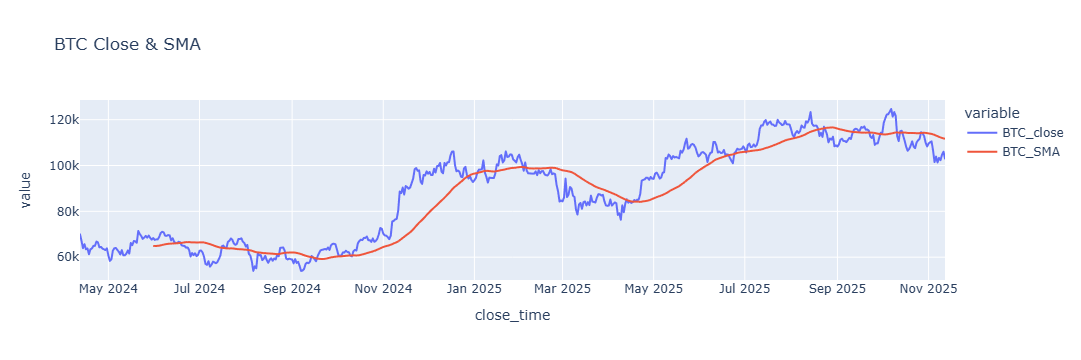

In [13]:
close = all_closes.copy()
open_ = all_opens.copy()

# Perf 5D de chaque symbole
ret_5d = close.pct_change(5)

# BTC perf & stats
btc = "BTCUSDT"
btc_ret_5d = ret_5d[btc]

# Médiane et écart-type roulants sur une periode
btc_median = btc_ret_5d.rolling(ROLL_LOOKBACK, min_periods=30).median()
btc_std = btc_ret_5d.rolling(ROLL_LOOKBACK, min_periods=30).std()

# Condition "BTC PERFORMANCE" 
# shift(1) pour select la serie passé et evite le data leakage
btc_strong = (btc_ret_5d.shift(1) > (btc_median.shift(1) + btc_std.shift(1)))

# SMA_X de BTC 
SMA_X = 50              # SMA moyen terme
btc_sma = close[btc].rolling(SMA_X, min_periods=SMA_X).mean()
btc_above_sma = (close[btc].shift(1) > btc_sma.shift(1))

# Condition globale d’entrée (jour J, calculée avec infos jusqu’à J-1)
entry_market_ok = (btc_strong & btc_above_sma)

# Sélection de l’actif momentum (top perf 5D) **hors BTC**, infos jusqu’à J-1
universe = [s for s in TOP_SYMBOLS]
ret_5d_shifted = ret_5d[universe].shift(1)  # pas de fuite
best_symbol_each_day = ret_5d_shifted.idxmax(axis=1)  # symbole avec meilleure perf 5D hier

# %% [markdown]
# ## 3) Règles d’allocation & construction des signaux
# - Si `entry_market_ok` est vrai au **jour J**, on entre à **J (close)** sur le **meilleur symbole**.
# - Sorties:
#   - **Vendredi** (weekday==4)
#   - OU si l’actif **sous-performe la moyenne** des retours journaliers de l’univers **3 jours consécutifs** depuis l’entrée.
#
# On va générer des matrices `entries` / `exits` (bool) par symbole, puis construire un portefeuille vectorbt.

# %%
daily_ret = close.pct_change(1)
basket_avg_ret = daily_ret[universe].mean(axis=1)

dates = close.index
symbols = universe.copy()  # on n'achète pas BTC lui-même

# Matrices vides
entries = pd.DataFrame(False, index=dates, columns=symbols)
exits   = pd.DataFrame(False, index=dates, columns=symbols)

# État du backtest (simple boucle) pour gérer les sorties conditionnelles
current_pos = None   # (symbol, entry_date)
underperf_streak = 0

for i, dt in enumerate(dates):
    # 1) Si position en cours, vérifier la sortie
    if current_pos is not None:
        sym, entry_dt = current_pos

        # a) sortie vendredi
        if dt.weekday() == 4:
            exits.loc[dt, sym] = True
            current_pos = None
            underperf_streak = 0
            continue

        # b) sous-performance 3 jours de suite vs moyenne (uniquement après l'entrée)
        #    On ne compte que les jours **après** l'entrée
        if dt > entry_dt:
            r_sym = daily_ret.at[dt, sym]
            r_avg = basket_avg_ret.at[dt]
            if pd.notna(r_sym) and pd.notna(r_avg):
                if r_sym < r_avg:
                    underperf_streak += 1
                else:
                    underperf_streak = 0

                if underperf_streak >= 3:
                    exits.loc[dt, sym] = True
                    current_pos = None
                    underperf_streak = 0
                    continue

    # 2) Si pas de position, regarder l'entrée
    if current_pos is None:
        if entry_market_ok.get(dt, False):
            # choisir le meilleur symbole du jour (calculé avec données J-1)
            best_sym = best_symbol_each_day.get(dt, None)
            if best_sym in symbols:
                entries.loc[dt, best_sym] = True
                current_pos = (best_sym, dt)
                underperf_streak = 0

# Important : si on arrive à la fin avec une position encore ouverte, on la clôture le dernier jour
if current_pos is not None:
    sym, _ = current_pos
    exits.iloc[-1, exits.columns.get_loc(sym)] = True
    current_pos = None
    underperf_streak = 0

# %% [markdown]
# ## 4) Portefeuille vectorbt (from_signals)
# - Achat/Vente au **close** (signal day)
# - Frais et slippage paramétrables
# - Base en USDT (on suppose des paires *USDT*)

# %%
# Prix utilisés pour exécution (close)
price = close[symbols]

# Frais (bps → fraction)
fees = FEES_BPS / 1e4
slippage = SLIPPAGE_BPS / 1e4

pf = vbt.Portfolio.from_signals(
    close=price,
    entries=entries,
    exits=exits,
    fees=fees,
    slippage=slippage,
    init_cash=10000.0,          # capital initial
    cash_sharing=True,          # un seul cash pool
    size=np.nan,                # full allocation sur chaque entrée (tout le cash)  
    freq='D'
)

# %% [markdown]
# ## 5) Résultats & graphiques

# %%
# Stats globales
stats = pf.stats()
print(stats)

# Equity curve
fig = pf.value().vbt.plot(title="Évolution du portefeuille (USDT)")
fig.show()

# Perf par symbole (PNL cumulé)
pnl_by_symbol = pf.trades.records_readable
# Aperçu des trades
display(pnl_by_symbol.head(20))

# Courbe BTC et indicateurs (sanity check)
debug_df = pd.DataFrame({
    "BTC_close": close[btc],
    "BTC_SMA": btc_sma,
    "BTC_5D": btc_ret_5d,
    "BTC_median_lookback": btc_median,
    "BTC_std_lookback": btc_std,
    "BTC_strong_cond": btc_strong.astype(int),
    "BTC_above_SMA": btc_above_sma.astype(int),
    "Entry_OK": entry_market_ok.astype(int)
})
display(debug_df.tail(15))

fig2 = px.line(debug_df[["BTC_close","BTC_SMA"]], title="BTC Close & SMA")
fig2.show()


In [2]:



# %%
import os
import math
import time
import json
import requests
from datetime import datetime, timedelta, timezone
import numpy as np
import pandas as pd
import vectorbt as vbt
import plotly.express as px

# Répertoires / paramètres
DATA_DIR = "crypto_data"
os.makedirs(DATA_DIR, exist_ok=True)

TOP_SYMBOLS = [
    "BTCUSDT", "ETHUSDT", "BNBUSDT", "SOLUSDT", "XRPUSDT",
    "ADAUSDT", "DOGEUSDT", "AVAXUSDT", "LINKUSDT", "TAOUSDT", "FETUSDT", "SUIUSDT", "AAVEUSDT"
]

API_BASE = "https://api.binance.com"
INTERVAL = "1d"
START_DATE = "2020-01-01"
SMA_X = 50              # SMA moyen terme
ROLL_LOOKBACK = 600     # fenêtre en jours pour médiane/écart-type des perfs 5D
MAX_SYMBOLS_PER_REQUEST = 1000  # limite de klines par appel
SLIPPAGE_BPS = 0        # glissement (0 = simplifié)
FEES_BPS = 6            # 0.06% par trade par ex. (ajuste si besoin)
TZ = "UTC"              # Les timestamps Binance sont en ms UTC

# %% [markdown]
# ## 1) Téléchargement/caching des données Binance (klines 1D)

# %%
def binance_klines(symbol, interval, start_dt):
    """Télécharge toutes les bougies 1D pour `symbol` depuis `start_dt` (UTC) via pagination.
       Retourne un DataFrame indexé par date (UTC) avec colonnes: open, high, low, close, volume.
    """
    url = f"{API_BASE}/api/v3/klines"
    start_ms = int(pd.Timestamp(start_dt, tz="UTC").timestamp() * 1000)
    all_rows = []
    while True:
        params = {
            "symbol": symbol,
            "interval": interval,
            "startTime": start_ms,
            "limit": MAX_SYMBOLS_PER_REQUEST
        }
        r = requests.get(url, params=params, timeout=30)
        r.raise_for_status()
        rows = r.json()
        if not rows:
            break
        all_rows.extend(rows)
        # Pagination: prochain start = dernier close_time + 1 ms
        last_close_ms = rows[-1][6]
        next_start_ms = last_close_ms + 1
        if next_start_ms == start_ms:
            break
        start_ms = next_start_ms
        # petit sleep pour être gentil avec l'API
        time.sleep(0.1)

    if not all_rows:
        return pd.DataFrame()

    cols = [
        "open_time","open","high","low","close","volume",
        "close_time","quote_asset_volume","number_of_trades",
        "taker_buy_base_vol","taker_buy_quote_vol","ignore"
    ]
    df = pd.DataFrame(all_rows, columns=cols)
    df["open_time"] = pd.to_datetime(df["open_time"], unit="ms", utc=True)
    df["close_time"] = pd.to_datetime(df["close_time"], unit="ms", utc=True)
    num_cols = ["open","high","low","close","volume"]
    for c in num_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    # Index = close_time converti en date (on reste en daily UTC)
    # Tu peux préférer open_time selon ton workflow
    df = df.set_index("close_time").sort_index()
    # On garde l'essentiel
    df = df[["open","high","low","close","volume"]]
    # Agg daily si nécessaire (klines 1d déjà day)
    return df

def load_or_download(symbol):
    path = os.path.join(DATA_DIR, f"{symbol}_{INTERVAL}.parquet")
    if os.path.exists(path):
        return pd.read_parquet(path)
    df = binance_klines(symbol, INTERVAL, START_DATE)
    if not df.empty:
        df.to_parquet(path)
    return df

# Télécharger toutes les séries
data_map = {}
for sym in TOP_SYMBOLS:
    print("Fetching:", sym)
    df = load_or_download(sym)
    data_map[sym] = df

# Harmoniser l'univers (intersection des dates disponibles)
all_closes = pd.concat(
    {sym: data_map[sym]["close"] for sym in TOP_SYMBOLS if not data_map[sym].empty},
    axis=1
).dropna(how="any")  # on retire les dates avec trous
all_opens = pd.concat(
    {sym: data_map[sym]["open"] for sym in TOP_SYMBOLS if not data_map[sym].empty},
    axis=1
).reindex(all_closes.index).dropna(how="any")

# %% [markdown]
# ## 2) Facteurs et signaux sans fuite d’info
# - Perf 5D (pct_change sur close 5 jours) → décalée (`shift(1)`) pour décision jour J
# - Pour BTC: médiane/écart-type roulants sur **LOOKBACK** j, décalés (`shift(1)`)
# - SMA_X sur BTC, décalée (`shift(1)`)

# %%
close = all_closes.copy()
open_ = all_opens.copy()

# Perf 5D de chaque symbole
ret_5d = close.pct_change(5)

# BTC perf & stats
btc = "BTCUSDT"
btc_ret_5d = ret_5d[btc]

# Médiane et écart-type roulants sur rétrospective
btc_median = btc_ret_5d.rolling(ROLL_LOOKBACK, min_periods=30).median()
btc_std = btc_ret_5d.rolling(ROLL_LOOKBACK, min_periods=30).std()

# Condition "BTC fort" (sans fuite) : on regarde les valeurs préalables à J
btc_strong = (btc_ret_5d.shift(1) > (btc_median.shift(1) + btc_std.shift(1)))

# SMA_X de BTC (sans fuite)
btc_sma = close[btc].rolling(SMA_X, min_periods=SMA_X).mean()
btc_above_sma = (close[btc].shift(1) > btc_sma.shift(1))

# Condition globale d’entrée (jour J, calculée avec infos jusqu’à J-1)
entry_market_ok = (btc_strong & btc_above_sma)

# Sélection de l’actif momentum (top perf 5D) **hors BTC**, infos jusqu’à J-1
universe = [s for s in TOP_SYMBOLS if s != btc]
ret_5d_shifted = ret_5d[universe].shift(1)  # pas de fuite
best_symbol_each_day = ret_5d_shifted.idxmax(axis=1)  # symbole avec meilleure perf 5D hier

# %% [markdown]
# ## 3) Règles d’allocation & construction des signaux
# - Si `entry_market_ok` est vrai au **jour J**, on entre à **J (close)** sur le **meilleur symbole**.
# - Sorties:
#   - **Vendredi** (weekday==4)
#   - OU si l’actif **sous-performe la moyenne** des retours journaliers de l’univers **3 jours consécutifs** depuis l’entrée.
#
# On va générer des matrices `entries` / `exits` (bool) par symbole, puis construire un portefeuille vectorbt.

# %%
daily_ret = close.pct_change(1)
basket_avg_ret = daily_ret[universe].mean(axis=1)

dates = close.index
symbols = universe.copy()  # on n'achète pas BTC lui-même

# Matrices vides
entries = pd.DataFrame(False, index=dates, columns=symbols)
exits   = pd.DataFrame(False, index=dates, columns=symbols)

# État du backtest (simple boucle) pour gérer les sorties conditionnelles
current_pos = None   # (symbol, entry_date)
underperf_streak = 0

for i, dt in enumerate(dates):
    # 1) Si position en cours, vérifier la sortie
    if current_pos is not None:
        sym, entry_dt = current_pos

        # a) sortie vendredi
        if dt.weekday() == 4:
            exits.loc[dt, sym] = True
            current_pos = None
            underperf_streak = 0
            continue

        # b) sous-performance 3 jours de suite vs moyenne (uniquement après l'entrée)
        #    On ne compte que les jours **après** l'entrée
        if dt > entry_dt:
            r_sym = daily_ret.at[dt, sym]
            r_avg = basket_avg_ret.at[dt]
            if pd.notna(r_sym) and pd.notna(r_avg):
                if r_sym < r_avg:
                    underperf_streak += 1
                else:
                    underperf_streak = 0

                if underperf_streak >= 3:
                    exits.loc[dt, sym] = True
                    current_pos = None
                    underperf_streak = 0
                    continue

    # 2) Si pas de position, regarder l'entrée
    if current_pos is None:
        if entry_market_ok.get(dt, False):
            # choisir le meilleur symbole du jour (calculé avec données J-1)
            best_sym = best_symbol_each_day.get(dt, None)
            if best_sym in symbols:
                entries.loc[dt, best_sym] = True
                current_pos = (best_sym, dt)
                underperf_streak = 0

# Important : si on arrive à la fin avec une position encore ouverte, on la clôture le dernier jour
if current_pos is not None:
    sym, _ = current_pos
    exits.iloc[-1, exits.columns.get_loc(sym)] = True
    current_pos = None
    underperf_streak = 0

# %% [markdown]
# ## 4) Portefeuille vectorbt (from_signals)
# - Achat/Vente au **close** (signal day)
# - Frais et slippage paramétrables
# - Base en USDT (on suppose des paires *USDT*)

# %%
# Prix utilisés pour exécution (close)
price = close[symbols]

# Frais (bps → fraction)
fees = FEES_BPS / 1e4
slippage = SLIPPAGE_BPS / 1e4

pf = vbt.Portfolio.from_signals(
    price=price,
    entries=entries,
    exits=exits,
    fees=fees,
    slippage=slippage,
    init_cash=10000.0,          # capital initial
    cash_sharing=True,          # un seul cash pool
    size=np.nan,                # full allocation sur chaque entrée (tout le cash)
    freq='D'
)

# %% [markdown]
# ## 5) Résultats & graphiques

# %%
# Stats globales
stats = pf.stats()
print(stats)

# Equity curve
fig = pf.value().vbt.plot(title="Évolution du portefeuille (USDT)")
fig.show()

# Perf par symbole (PNL cumulé)
pnl_by_symbol = pf.trades.records_readable
# Aperçu des trades
display(pnl_by_symbol.head(20))

# Courbe BTC et indicateurs (sanity check)
debug_df = pd.DataFrame({
    "BTC_close": close[btc],
    "BTC_SMA": btc_sma,
    "BTC_5D": btc_ret_5d,
    "BTC_median_lookback": btc_median,
    "BTC_std_lookback": btc_std,
    "BTC_strong_cond": btc_strong.astype(int),
    "BTC_above_SMA": btc_above_sma.astype(int),
    "Entry_OK": entry_market_ok.astype(int)
})
display(debug_df.tail(15))

fig2 = px.line(debug_df[["BTC_close","BTC_SMA"]], title="BTC Close & SMA")
fig2.show()

# %% [markdown]
# ## 6) Notes / Ajustements
# - La sélection "top perf 5D" est basée sur **J-1** (no leakage).
# - Entrée au **close J** si le signal est vrai, sortie au **close** du **vendredi** ou si sous-perf 3 jours consécutifs.
# - Tu peux changer `SMA_X`, `ROLL_LOOKBACK`, la liste `TOP_SYMBOLS`, les `FEES_BPS`.
# - Si tu veux entrer **lundi** seulement et sortir **vendredi** (strict weekly), on peut adapter la logique (rebal hebdo).
# - Si tu veux exécuter au **open J+1**, on peut décaler les signaux (`entries.shift(1)`) et utiliser `open_` pour les prix d’exécution.


Fetching: BTCUSDT
Fetching: ETHUSDT
Fetching: BNBUSDT
Fetching: SOLUSDT
Fetching: XRPUSDT
Fetching: ADAUSDT
Fetching: DOGEUSDT
Fetching: AVAXUSDT
Fetching: LINKUSDT
Fetching: TAOUSDT
Fetching: FETUSDT
Fetching: SUIUSDT
Fetching: AAVEUSDT


C:\Users\leoja\AppData\Local\Temp\ipykernel_16820\3387435698.py:148: FutureWarning: The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  best_symbol_each_day = ret_5d_shifted.idxmax(axis=1)  # symbole avec meilleure perf 5D hier


TypeError: Portfolio.from_signals() missing 1 required positional argument: 'close'

In [9]:
# === Configuration de la stratégie ===
ENTRY_THRESHOLD = 0.005  # 0.5% de rendement sur la session européenne
TRAILING_STOP = 0.015    # 1.5% de stop suiveur
POSITION_SIZE = 0.2      # 20% du capital par trade
RISK_FREE_RATE = 0.00    # Taux sans risque pour calcul Sharpe


Exemple de rendements BTC :
timestamp
2020-01-01 00:00:00+00:00    0.003379
2020-01-02 00:00:00+00:00    0.002813
2020-01-03 00:00:00+00:00    0.016370
2020-01-04 00:00:00+00:00   -0.003953
2020-01-05 00:00:00+00:00    0.000640
Freq: D, Name: return, dtype: float64

Statistiques descriptives :
count    1962.000000
mean        0.000847
std         0.019493
min        -0.170450
25%        -0.008227
50%         0.000309
75%         0.009482
max         0.150715
Name: return, dtype: float64


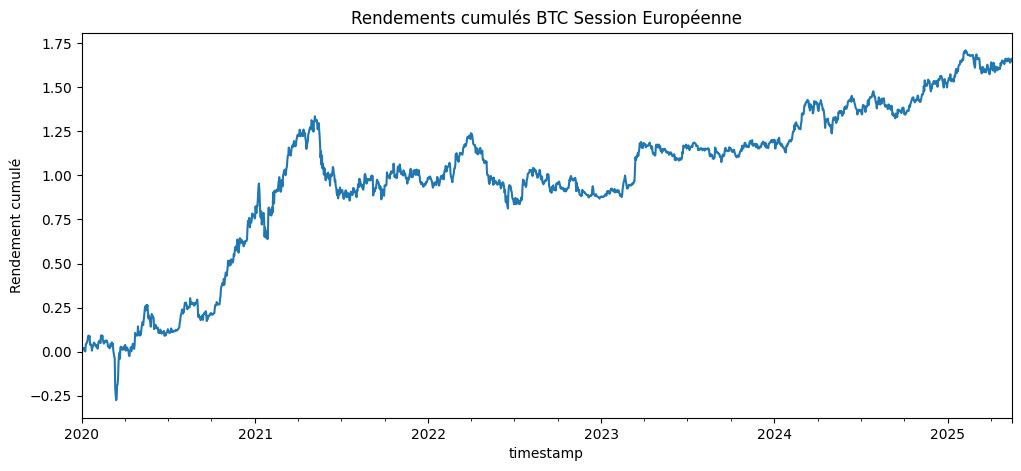

In [31]:
# %% Cellule 5 - Calcul des performances BTC (version corrigée)

def calculate_btc_performance():
    """Calcule le rendement BTC pendant la session européenne avec vérifications"""
    try:
        btc_data = all_data['BTCUSDT'].copy()
        
        # Conversion explicite en UTC
        btc_data.index = btc_data.index.tz_localize(None).tz_localize('UTC')
        
        # Filtrage de la session européenne (08h-15h UTC)
        europe_mask = (
            (btc_data.index.time >= pd.to_datetime('08:00:00').time()) & 
            (btc_data.index.time <= pd.to_datetime('15:00:00').time()))
        
        btc_europe = btc_data[europe_mask]
        
        if btc_europe.empty:
            raise ValueError("Aucune donnée BTC pendant la session européenne")
            
        # Agrégation quotidienne avec vérification
        daily_perf = btc_europe.resample('D').agg({
            'open': 'first',
            'close': 'last'
        }).dropna()
        
        # Calcul du rendement
        daily_perf['return'] = (daily_perf['close'] - daily_perf['open']) / daily_perf['open']
        
        # Vérification finale
        if daily_perf['return'].isna().any():
            print("Avertissement : Certains rendements sont NaN")
            daily_perf = daily_perf.dropna()
            
        return daily_perf['return']
    
    except KeyError:
        print("Erreur : Données BTC non chargées")
        return pd.Series()
    except Exception as e:
        print(f"Erreur inattendue : {str(e)}")
        return pd.Series()

# Exécution avec vérification
btc_returns = calculate_btc_performance()

if not btc_returns.empty:
    print("Exemple de rendements BTC :")
    print(btc_returns.head())
    print("\nStatistiques descriptives :")
    print(btc_returns.describe())
    
    plt.figure(figsize=(12, 5))
    btc_returns.cumsum().plot(title="Rendements cumulés BTC Session Européenne")
    plt.ylabel("Rendement cumulé")
    plt.show()
else:
    print("Aucun rendement calculé - vérifiez les données d'entrée")

In [1]:
def get_best_asset(current_date):
    """Trouve l'actif avec la meilleure performance sur 4 jours"""
    performances = {}
    for symbol, data in all_data.items():
        try:
            mask = (data.index >= current_date - pd.Timedelta(days=4)) & (data.index < current_date)
            returns = data[mask]['close'].pct_change().mean()
            performances[symbol] = returns
        except:
            continue
    return max(performances, key=performances.get) if performances else None

In [2]:
class TradingEngine:
    def __init__(self):
        self.capital = [10000]
        self.trades = []
    
    def execute_trade(self, symbol, entry_time):
        entry_price = all_data[symbol].loc[entry_time]['open']
        max_price = entry_price
        exit_price = None
        
        # Parcours des données H1 suivantes
        post_entry = all_data[symbol][all_data[symbol].index >= entry_time].iloc[:HOLDING_PERIOD]
        
        for idx, row in post_entry.iterrows():
            max_price = max(max_price, row['high'])
            if row['low'] <= max_price * (1 - TRAILING_STOP):
                exit_price = max_price * (1 - TRAILING_STOP)
                break
                
        exit_price = exit_price or post_entry.iloc[-1]['close']
        
        profit = (exit_price - entry_price) / entry_price
        self.capital.append(self.capital[-1] * (1 + profit * POSITION_SIZE))
        self.trades.append({
            'symbol': symbol,
            'entry': entry_time,
            'exit': idx,
            'return%': profit * 100,
            'duration': (idx - entry_time).total_seconds()/3600
        })
    
    def run_backtest(self):
        for date, ret in btc_returns[btc_returns > ENTRY_THRESHOLD].items():
            symbol = get_best_asset(date)
            if symbol:
                entry_time = date.replace(hour=16, minute=0)
                if entry_time in all_data[symbol].index:
                    self.execute_trade(symbol, entry_time)

In [3]:
# %% Test manuel de get_best_asset
test_dates = btc_returns[btc_returns > ENTRY_THRESHOLD].index[:5]  # Premières dates éligibles

for date in test_dates:
    best = get_best_asset(date)
    print(f"Date: {date.date()} -> Meilleur actif: {best}")
    
    if best:
        print("Données disponibles:")
        print(all_data[best].loc[date - pd.Timedelta(days=4):date].tail(8))

NameError: name 'btc_returns' is not defined

In [35]:
# Calcul des métriques
returns = pd.Series([t['return%'] for t in engine.trades])
capital = pd.Series(engine.capital)

metrics = {
    'Rendement total (%)': (capital.iloc[-1]/capital.iloc[0] - 1) * 100,
    'Sharp Ratio': returns.mean()/returns.std(),
    'Max Drawdown (%)': (1 - capital/capital.cummax()).max() * 100,
    'Taux de réussite (%)': (returns > 0).mean() * 100,
    'Performance moyenne (%)': returns.mean(),
}

# Affichage
print("=== PERFORMANCE ===")
for k, v in metrics.items():
    print(f"{k}: {v:.2f}")

# Visualisation
plt.figure(figsize=(14, 5))
plt.plot(capital)
plt.title("Évolution du capital")
plt.xlabel("Trades")
plt.ylabel("Valeur (€)")
plt.grid(True)
plt.show()

NameError: name 'engine' is not defined


Lorsque le Bitcoin affiche une performance hebdomadaire significativement supérieure à sa moyenne historique — c’est-à-dire que sa performance sur 5 jours dépasse la médiane 5 jours + 1 écart-type — et qu’il évolue au-dessus de sa moyenne mobile moyen terme depuis, cela traduit un contexte haussier fort du marché crypto.

Dans cette configuration, on s’expose à la crypto la plus performante parmi le top 15 des capitalisations au cours des 5 derniers jours (celle dont le rendement cumulé sur 5 jours est le plus élevé), afin de capter un effet de momentum sectoriel à effet de mode amplifié par la tendance dominante du Bitcoin.


In [6]:

pip install pyarrow


   ---------------------------------------- 0.0/28.1 MB ? eta -:--:--
   -- ------------------------------------- 1.5/28.1 MB 46.6 MB/s eta 0:00:01
   ---- ----------------------------------- 2.8/28.1 MB 30.0 MB/s eta 0:00:01
   ------ --------------------------------- 4.5/28.1 MB 31.9 MB/s eta 0:00:01
   ------- -------------------------------- 5.4/28.1 MB 34.9 MB/s eta 0:00:01
   --------- ------------------------------ 6.9/28.1 MB 31.4 MB/s eta 0:00:01
   ----------- ---------------------------- 8.0/28.1 MB 32.1 MB/s eta 0:00:01
   ------------- -------------------------- 9.5/28.1 MB 32.0 MB/s eta 0:00:01
   --------------- ------------------------ 10.9/28.1 MB 31.2 MB/s eta 0:00:01
   ----------------- ---------------------- 12.4/28.1 MB 31.2 MB/s eta 0:00:01
   ------------------ --------------------- 13.3/28.1 MB 31.2 MB/s eta 0:00:01
   --------------------- ------------------ 15.3/28.1 MB 32.7 MB/s eta 0:00:01
   ----------------------- ---------------- 16.2/28.1 MB 31.2 MB/s e


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: C:\Users\leoja\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip
